Companion notebook for *A Probabilistic Mixture Model for Evaluating Sound Localisation Performance in the Median Plane* (Sztandera, Picinali, Barumerli, Forum Acusticum 2026). Run it from the repository root; it reads `data/AXD_measured.csv` (see `data/README.md`).

# AXD Behavioral Metrics

Compute localization metrics for each participant in the **Measured** condition of the AXD dataset.

**Metrics**:
- `accP` — polar bias (°)
- `querrMiddlebrooks` — quadrant error rate (%)
- `rmsPmedianlocal` — local polar RMS error (°)
- Mixture model MLE (pyBADS): `w_hat` (correct-hemifield weight), `kappa_hat` (polar concentration), and `sigma_hat` (polar precision, °)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from metrics import accP_cutoff, querrMiddlebrooks, rmsPmedianlocal, wrap_polar_angle
from bayesian_metric import (
    sigma_to_kappa, kappa_to_sigma, polar_mirror,
    fit_mixture_querr,
)

## Load data

In [2]:
obs_tbl = pd.read_csv('data/AXD_measured.csv')   # Measured condition only
obs_tbl = obs_tbl[obs_tbl['participant'] != 'P0247']
obs_tbl = obs_tbl.reset_index(drop=True)

participants = sorted(obs_tbl['participant'].unique())
print(f'{len(participants)} participants, {len(obs_tbl)} trials')
# print(obs_tbl.groupby('participant').size().to_string())

33 participants, 5643 trials


## Mixture model helpers

Fits a two-component von Mises mixture in polar angle for central targets (|lat_target| ≤ 30°):

$$p(\phi | \phi_t) = w \cdot \text{VM}(\phi_t, \kappa) + (1-w) \cdot \text{VM}(\pi - \phi_t, \kappa)$$

- `w`: correct-hemifield weight (≈ 1 − querr/100)
- `σ_mix`: polar precision in degrees (from fitted κ)

## Mixture model

Fits a two-component von Mises mixture in polar angle for central targets (|lat_target| ≤ 30°):

$$p(\phi | \phi_t) = w \cdot \text{VM}(\phi_t, \kappa) + (1-w) \cdot \text{VM}(\pi - \phi_t, \kappa)$$

- `w`: correct-hemifield weight (≈ 1 − querr/100)
- `σ_mix`: polar precision in degrees (from fitted κ)

Model helpers are defined in `bayesian_metric.py`.

In [3]:
import joblib

N_SYNTH  = 30
N_TRIALS = 99
SEED     = 42

rng = np.random.default_rng(SEED)

# Pool of central targets from real AXD data
central_rows = obs_tbl[
    np.abs(obs_tbl['lat_target']) <= 30.0
][['lat_target', 'pol_target']].reset_index(drop=True)

# True parameters — sampled independently (uncorrelated)
w_true_rec         = rng.uniform(0.5, 1.0, N_SYNTH)
log_kappa_true_rec = rng.uniform(
    np.log(sigma_to_kappa(70.0)),
    np.log(sigma_to_kappa(10.0)),
    N_SYNTH,
)
kappa_true_rec = np.exp(log_kappa_true_rec)
sigma_true_rec = np.array([kappa_to_sigma(k) for k in kappa_true_rec])

# Generate one synthetic participant DataFrame
def _make_synth_df(seed, lat_t_deg, pol_t_deg, w, kappa):
    rng_loc     = np.random.default_rng(seed)
    pol_t       = np.deg2rad(pol_t_deg)
    use_correct = rng_loc.random(len(pol_t)) < w
    mu          = np.where(use_correct, pol_t, polar_mirror(pol_t))
    pol_resp    = wrap_polar_angle(rng_loc.vonmises(mu, kappa))
    return pd.DataFrame({
        'lat_target':   lat_t_deg,
        'pol_target':   pol_t_deg,
        'pol_response': np.rad2deg(pol_resp),
    })

seeds      = rng.integers(0, 2**31, N_SYNTH)
trial_idxs = [rng.choice(len(central_rows), size=N_TRIALS, replace=True)
              for _ in range(N_SYNTH)]

synth_dfs = [
    _make_synth_df(
        seeds[i],
        central_rows.iloc[trial_idxs[i]]['lat_target'].values,
        central_rows.iloc[trial_idxs[i]]['pol_target'].values,
        w_true_rec[i],
        kappa_true_rec[i],
    )
    for i in range(N_SYNTH)
]

# Fit in parallel (loky backend uses cloudpickle for notebook-defined functions)
recovery_results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(fit_mixture_querr)(df) for df in synth_dfs
)

w_hat_rec     = np.array([r['w_hat']     for r in recovery_results])
kappa_hat_rec = np.array([r['kappa_hat'] for r in recovery_results])
sigma_hat_rec = np.array([r['sigma_hat'] for r in recovery_results])
confusion_hat_rec = (1 - w_hat_rec) * 100

# Behavioral metrics from synthetic and retrieved data.
# The mixture model has no lateral noise: lat_response = lat_target.
def _behavioral_metrics(df):
    true_hp = np.column_stack([np.deg2rad(df['lat_target'].values),
                                np.deg2rad(df['pol_target'].values)])
    est_hp  = np.column_stack([np.deg2rad(df['lat_target'].values),
                                np.deg2rad(df['pol_response'].values)])
    return (querrMiddlebrooks(true_hp, est_hp)[0],
            np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0]))

# Metrics from true synthetic responses
beh_synth       = [_behavioral_metrics(df) for df in synth_dfs]
querr_synth     = np.array([b[0] for b in beh_synth])
rmsPlocal_synth = np.array([b[1] for b in beh_synth])

# Metrics from responses generated with the retrieved (fitted) parameters — same targets
seeds_ret  = rng.integers(0, 2**31, N_SYNTH)
ret_dfs    = [
    _make_synth_df(
        seeds_ret[i],
        central_rows.iloc[trial_idxs[i]]['lat_target'].values,
        central_rows.iloc[trial_idxs[i]]['pol_target'].values,
        w_hat_rec[i],
        kappa_hat_rec[i],
    )
    for i in range(N_SYNTH)
]
beh_ret       = [_behavioral_metrics(df) for df in ret_dfs]
querr_ret     = np.array([b[0] for b in beh_ret])
rmsPlocal_ret = np.array([b[1] for b in beh_ret])

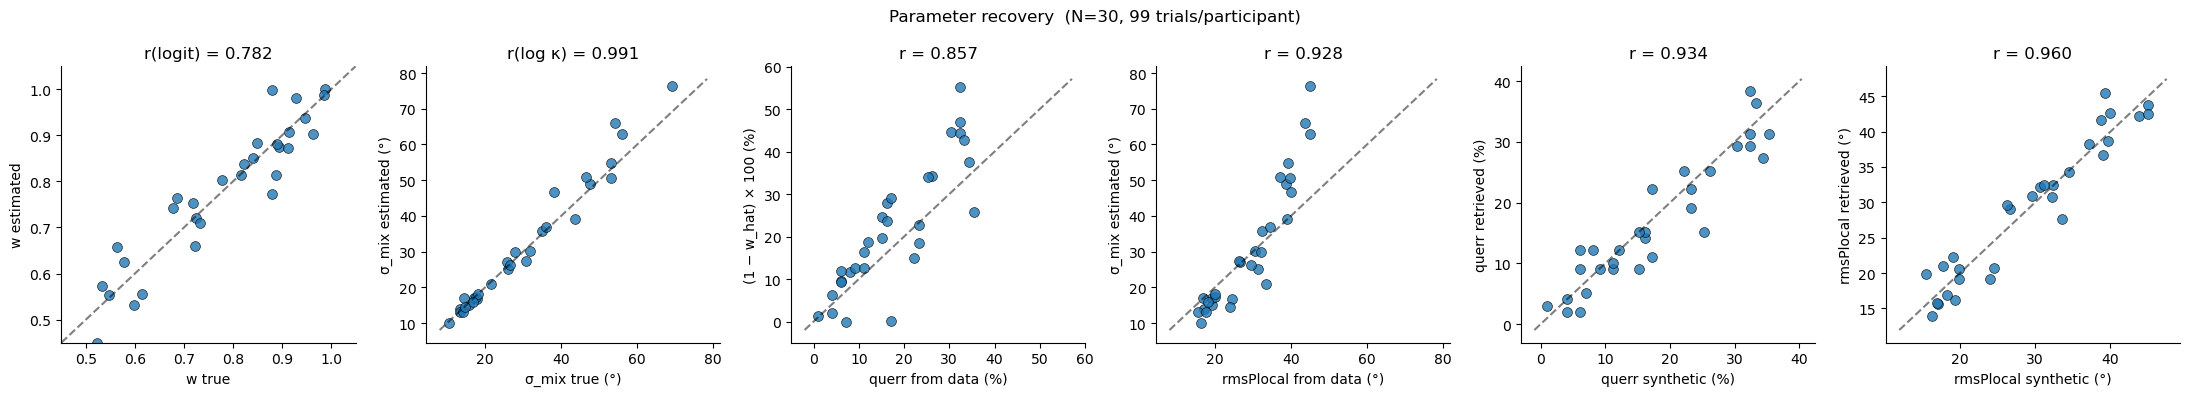

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
fig.suptitle('Parameter recovery  (N=30, 99 trials/participant)', fontsize=12)

logit = lambda p: np.log(p / (1 - p))

# Panel 1: w — correlation in logit space
ax    = axes[0]
r_w   = np.corrcoef(logit(w_true_rec), logit(w_hat_rec))[0, 1]
lims_w = [0.45, 1.05]
ax.scatter(w_true_rec, w_hat_rec, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_w, lims_w, 'k--', lw=1.5, alpha=0.5)
ax.set_xlim(lims_w); ax.set_ylim(lims_w)
ax.set_xlabel('w true')
ax.set_ylabel('w estimated')
ax.set_title(f'r(logit) = {r_w:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: σ_mix — correlation in log-κ space
ax    = axes[1]
r_k   = np.corrcoef(np.log(kappa_true_rec), np.log(kappa_hat_rec))[0, 1]
lims_s = [min(sigma_true_rec.min(), sigma_hat_rec.min()) - 2,
          max(sigma_true_rec.max(), sigma_hat_rec.max()) + 2]
ax.scatter(sigma_true_rec, sigma_hat_rec, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_s, lims_s, 'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('σ_mix true (°)')
ax.set_ylabel('σ_mix estimated (°)')
ax.set_title(f'r(log κ) = {r_k:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: querr from synthetic data vs confusion from fitted model
ax    = axes[2]
r_q   = np.corrcoef(querr_synth, confusion_hat_rec)[0, 1]
lims_q = [min(querr_synth.min(), confusion_hat_rec.min()) - 2,
          max(querr_synth.max(), confusion_hat_rec.max()) + 2]
ax.scatter(querr_synth, confusion_hat_rec, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_q, lims_q, 'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('querr from data (%)')
ax.set_ylabel('(1 − w_hat) × 100 (%)')
ax.set_title(f'r = {r_q:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 4: rmsPlocal from synthetic data vs sigma from fitted model
ax    = axes[3]
r_rms = np.corrcoef(rmsPlocal_synth, sigma_hat_rec)[0, 1]
lims_r = [min(rmsPlocal_synth.min(), sigma_hat_rec.min()) - 2,
          max(rmsPlocal_synth.max(), sigma_hat_rec.max()) + 2]
ax.scatter(rmsPlocal_synth, sigma_hat_rec, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_r, lims_r, 'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('rmsPlocal from data (°)')
ax.set_ylabel('σ_mix estimated (°)')
ax.set_title(f'r = {r_rms:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 5: querr — synthetic vs retrieved
ax    = axes[4]
r_qr  = np.corrcoef(querr_synth, querr_ret)[0, 1]
lims_qr = [min(querr_synth.min(), querr_ret.min()) - 2,
           max(querr_synth.max(), querr_ret.max()) + 2]
ax.scatter(querr_synth, querr_ret, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_qr, lims_qr, 'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('querr synthetic (%)')
ax.set_ylabel('querr retrieved (%)')
ax.set_title(f'r = {r_qr:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 6: rmsPlocal — synthetic vs retrieved
ax    = axes[5]
r_rr  = np.corrcoef(rmsPlocal_synth, rmsPlocal_ret)[0, 1]
lims_rr = [min(rmsPlocal_synth.min(), rmsPlocal_ret.min()) - 2,
           max(rmsPlocal_synth.max(), rmsPlocal_ret.max()) + 2]
ax.scatter(rmsPlocal_synth, rmsPlocal_ret, s=50, edgecolors='black', linewidths=0.5, alpha=0.8)
ax.plot(lims_rr, lims_rr, 'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('rmsPlocal synthetic (°)')
ax.set_ylabel('rmsPlocal retrieved (°)')
ax.set_title(f'r = {r_rr:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Compute metrics per participant

In [5]:
rows = []
for pid in participants:
    df = obs_tbl[obs_tbl['participant'] == pid]

    # Build (n_trials, 2) arrays in radians for metrics.py
    true_hp = np.column_stack([np.deg2rad(df['lat_target'].values),
                                np.deg2rad(df['pol_target'].values)])
    est_hp  = np.column_stack([np.deg2rad(df['lat_response'].values),
                                np.deg2rad(df['pol_response'].values)])

    row = {'participant': pid, 'n_trials': len(df)}

    row['accP_deg']        = np.rad2deg(accP_cutoff(true_hp, est_hp)[0])
    row['querr_pct']       = querrMiddlebrooks(true_hp, est_hp)[0]
    row['rmsPlocal_deg']   = np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0])

    mix = fit_mixture_querr(df)
    row['w_hat']           = mix['w_hat']
    row['kappa_hat']       = mix['kappa_hat']
    row['sigma_mix_deg']   = mix['sigma_hat']
    row['confusion_pct']   = (1 - mix['w_hat']) * 100
    row['n_central']       = mix['n_trials']

    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index('participant')

## Summary statistics

In [6]:
cols = ['accP_deg', 'querr_pct', 'rmsPlocal_deg', 'sigma_mix_deg', 'confusion_pct']
metrics_df[cols].describe().round(2)

,accP_deg,querr_pct,rmsPlocal_deg,sigma_mix_deg,confusion_pct
count,33.00,33.00,33.00,33.00,33.00
mean,0.23,15.09,33.79,38.48,14.59
std,13.81,10.62,6.24,10.85,11.54
min,-29.67,0.00,16.17,18.83,0.00
25%,-12.11,7.35,30.24,32.30,6.18
50%,0.57,12.96,34.49,36.99,10.79
75%,10.87,18.75,37.67,43.00,19.32
max,33.84,43.59,43.60,60.60,47.27


## Plots

### Mixture model vs threshold-based metrics

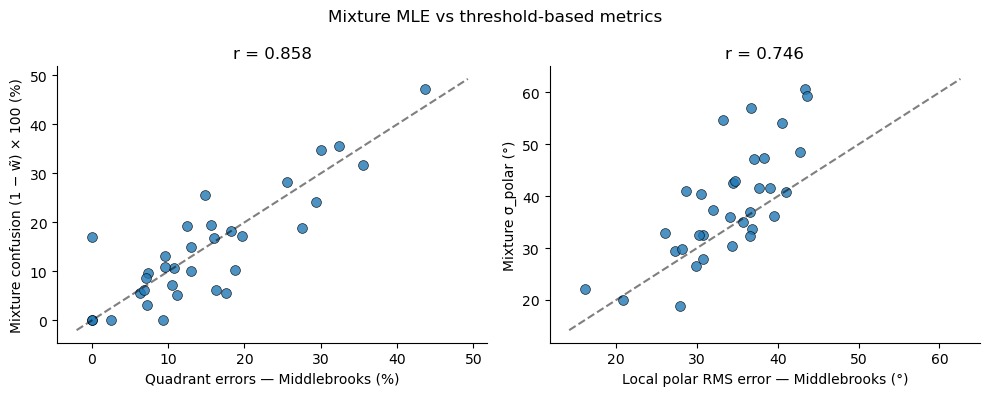

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Mixture MLE vs threshold-based metrics', fontsize=12)

# Panel 1: confusion_pct vs querrMiddlebrooks
ax = axes[0]
x_vals = metrics_df['querr_pct'].values
y_vals = metrics_df['confusion_pct'].values
mask   = np.isfinite(x_vals) & np.isfinite(y_vals)
ax.scatter(x_vals[mask], y_vals[mask], s=50, alpha=0.8, edgecolors='black', linewidths=0.5)
lims = [min(x_vals[mask].min(), y_vals[mask].min()) - 2,
        max(x_vals[mask].max(), y_vals[mask].max()) + 2]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5)
r = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Quadrant errors — Middlebrooks (%)')
ax.set_ylabel('Mixture confusion (1 − w̃) × 100 (%)')
ax.set_title(f'r = {r:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: sigma_mix vs rmsPmedianlocal
ax = axes[1]
x_vals = metrics_df['rmsPlocal_deg'].values
y_vals = metrics_df['sigma_mix_deg'].values
mask   = np.isfinite(x_vals) & np.isfinite(y_vals)
ax.scatter(x_vals[mask], y_vals[mask], s=50, alpha=0.8, edgecolors='black', linewidths=0.5)
lims = [min(x_vals[mask].min(), y_vals[mask].min()) - 2,
        max(x_vals[mask].max(), y_vals[mask].max()) + 2]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5)
r = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Local polar RMS error — Middlebrooks (°)')
ax.set_ylabel('Mixture σ_polar (°)')
ax.set_title(f'r = {r:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()